In [1]:
from langgraph.graph import StateGraph,END,START
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import HumanMessage,SystemMessage,BaseMessage
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
import os
import operator
from langgraph.checkpoint.memory import InMemorySaver # store in ram
from dotenv import load_dotenv

In [2]:
load_dotenv()
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)


In [3]:
class JokeState(TypedDict):

    topic : str
    joke : str
    explanation : str


In [4]:
def generate_joke(state : JokeState) -> JokeState:

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt)

    return {'joke': response}

In [5]:
def generate_explaination(state : JokeState) -> JokeState:

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt)

    return {'explanation' : response}

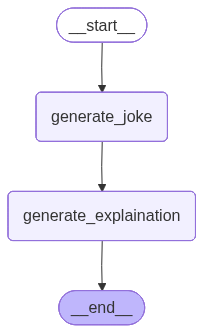

In [6]:
graph = StateGraph(JokeState)

# add Node
graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explaination',generate_explaination)

# add Edge
graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explaination')
graph.add_edge('generate_explaination',END)

# compike
checkpointer = InMemorySaver() # implementing persistence
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [7]:
# invoke
thread_id1 = '1'
config1 = {"configurable" : {"thread_id" : thread_id1}}

initial_state1 = {
    'topic' : 'pizza'
}

workflow.invoke(initial_state1,config=config1)

{'topic': 'pizza',
 'joke': AIMessage(content='Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 42, 'total_tokens': 62, 'completion_time': 0.030359975, 'completion_tokens_details': None, 'prompt_time': 0.002017151, 'prompt_tokens_details': None, 'queue_time': 0.045096969, 'total_time': 0.032377126}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d3cb-74f0-95b1-f59ac450c3d8-0', usage_metadata={'input_tokens': 42, 'output_tokens': 20, 'total_tokens': 62}),
 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. The setup "Why did the pizza go to the doctor?" is a common format for a joke, implying that the pizza is experiencing some kind of problem that requires medical attention.\n\nThe punchline "Beca

In [8]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content='Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 42, 'total_tokens': 62, 'completion_time': 0.030359975, 'completion_tokens_details': None, 'prompt_time': 0.002017151, 'prompt_tokens_details': None, 'queue_time': 0.045096969, 'total_time': 0.032377126}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d3cb-74f0-95b1-f59ac450c3d8-0', usage_metadata={'input_tokens': 42, 'output_tokens': 20, 'total_tokens': 62}), 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. The setup "Why did the pizza go to the doctor?" is a common format for a joke, implying that the pizza is experiencing some kind of problem that requires medical attention.\n\n

In [9]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content='Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 42, 'total_tokens': 62, 'completion_time': 0.030359975, 'completion_tokens_details': None, 'prompt_time': 0.002017151, 'prompt_tokens_details': None, 'queue_time': 0.045096969, 'total_time': 0.032377126}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d3cb-74f0-95b1-f59ac450c3d8-0', usage_metadata={'input_tokens': 42, 'output_tokens': 20, 'total_tokens': 62}), 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. The setup "Why did the pizza go to the doctor?" is a common format for a joke, implying that the pizza is experiencing some kind of problem that requires medical attention.\n\

In [10]:
thread_id2 = '2'
config2 = {"configurable" : {"thread_id" : thread_id2}}

initial_state2 = {
    'topic' : 'banana'
}
workflow.invoke(initial_state2,config=config2)

{'topic': 'banana',
 'joke': AIMessage(content="Why did the banana go to the doctor? \n\nBecause it wasn't peeling well.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 42, 'total_tokens': 61, 'completion_time': 0.022164612, 'completion_tokens_details': None, 'prompt_time': 0.001958204, 'prompt_tokens_details': None, 'queue_time': 0.046612116, 'total_time': 0.024122816}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d6cb-7e72-8a5d-6aa6d69fab2b-0', usage_metadata={'input_tokens': 42, 'output_tokens': 19, 'total_tokens': 61}),
 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. The setup "Why did the banana go to the doctor?" is a common format for a joke, implying that the banana is ill or injured in some way.\n\nThe punchline "Because it wasn\'t peeling well" is where the p

In [11]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'banana', 'joke': AIMessage(content="Why did the banana go to the doctor? \n\nBecause it wasn't peeling well.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 42, 'total_tokens': 61, 'completion_time': 0.022164612, 'completion_tokens_details': None, 'prompt_time': 0.001958204, 'prompt_tokens_details': None, 'queue_time': 0.046612116, 'total_time': 0.024122816}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d6cb-7e72-8a5d-6aa6d69fab2b-0', usage_metadata={'input_tokens': 42, 'output_tokens': 19, 'total_tokens': 61}), 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. The setup "Why did the banana go to the doctor?" is a common format for a joke, implying that the banana is ill or injured in some way.\n\nThe punchline "Because it wasn\'t peeling w

In [12]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'banana', 'joke': AIMessage(content="Why did the banana go to the doctor? \n\nBecause it wasn't peeling well.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 42, 'total_tokens': 61, 'completion_time': 0.022164612, 'completion_tokens_details': None, 'prompt_time': 0.001958204, 'prompt_tokens_details': None, 'queue_time': 0.046612116, 'total_time': 0.024122816}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d6cb-7e72-8a5d-6aa6d69fab2b-0', usage_metadata={'input_tokens': 42, 'output_tokens': 19, 'total_tokens': 61}), 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. The setup "Why did the banana go to the doctor?" is a common format for a joke, implying that the banana is ill or injured in some way.\n\nThe punchline "Because it wasn\'t peeling 

## Time Travel

In [13]:
history1 = list(workflow.get_state_history(config1))
replay_config = next(
    snapshot.config
    for snapshot in history1
    if snapshot.values.get("joke") and not snapshot.values.get("explanation")
)
workflow.get_state(replay_config)

StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content='Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 42, 'total_tokens': 62, 'completion_time': 0.030359975, 'completion_tokens_details': None, 'prompt_time': 0.002017151, 'prompt_tokens_details': None, 'queue_time': 0.045096969, 'total_time': 0.032377126}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d3cb-74f0-95b1-f59ac450c3d8-0', usage_metadata={'input_tokens': 42, 'output_tokens': 20, 'total_tokens': 62})}, next=('generate_explaination',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f11ef30-eb71-6a20-8001-c0639c6a6836'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-13T15:41:09.796277+00:00', parent_co

In [14]:
workflow.invoke(None, replay_config)

{'topic': 'pizza',
 'joke': AIMessage(content='Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 42, 'total_tokens': 62, 'completion_time': 0.030359975, 'completion_tokens_details': None, 'prompt_time': 0.002017151, 'prompt_tokens_details': None, 'queue_time': 0.045096969, 'total_time': 0.032377126}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d3cb-74f0-95b1-f59ac450c3d8-0', usage_metadata={'input_tokens': 42, 'output_tokens': 20, 'total_tokens': 62}),
 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. The setup "Why did the pizza go to the doctor?" is a common format for a joke, implying that the pizza is experiencing some kind of problem that requires medical attention.\n\nThe punchline "Beca

In [15]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': AIMessage(content='Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 42, 'total_tokens': 62, 'completion_time': 0.030359975, 'completion_tokens_details': None, 'prompt_time': 0.002017151, 'prompt_tokens_details': None, 'queue_time': 0.045096969, 'total_time': 0.032377126}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d3cb-74f0-95b1-f59ac450c3d8-0', usage_metadata={'input_tokens': 42, 'output_tokens': 20, 'total_tokens': 62}), 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. The setup "Why did the pizza go to the doctor?" is a common format for a joke, implying that the pizza is experiencing some kind of problem that requires medical attention.\n\

## Updating State

In [16]:
update_base_config = workflow.get_state(replay_config).parent_config
updated_config = workflow.update_state(
    update_base_config,
    {"topic": "samosa"},
    as_node="__start__"
)
updated_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f11ef30-fa35-621e-8001-d553c9a56a45'}}

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': AIMessage(content='Why did the pizza go to the doctor? \n\nBecause it was feeling a little crusty.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 42, 'total_tokens': 62, 'completion_time': 0.030359975, 'completion_tokens_details': None, 'prompt_time': 0.002017151, 'prompt_tokens_details': None, 'queue_time': 0.045096969, 'total_time': 0.032377126}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-d3cb-74f0-95b1-f59ac450c3d8-0', usage_metadata={'input_tokens': 42, 'output_tokens': 20, 'total_tokens': 62})}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f11ef30-fa35-621e-8001-d553c9a56a45'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-13T15:41:11.344379+00:00', parent_config

In [18]:
workflow.invoke(None, updated_config)

{'topic': 'samosa',
 'joke': AIMessage(content='Why did the samosa go to therapy? \n\nBecause it was feeling crumby and had a lot of filling issues.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 43, 'total_tokens': 69, 'completion_time': 0.037924535, 'completion_tokens_details': None, 'prompt_time': 0.002090784, 'prompt_tokens_details': None, 'queue_time': 0.045641966, 'total_time': 0.040015319}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-db4c-7a11-b527-998b218b48b5-0', usage_metadata={'input_tokens': 43, 'output_tokens': 26, 'total_tokens': 69}),
 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. Here\'s a breakdown of the joke:\n\n- "Why did the samosa go to therapy?" is the setup for the joke, asking the listener to imagine a situation where a samosa (a type of Ind

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': AIMessage(content='Why did the samosa go to therapy? \n\nBecause it was feeling crumby and had a lot of filling issues.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 43, 'total_tokens': 69, 'completion_time': 0.037924535, 'completion_tokens_details': None, 'prompt_time': 0.002090784, 'prompt_tokens_details': None, 'queue_time': 0.045641966, 'total_time': 0.040015319}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce7db-db4c-7a11-b527-998b218b48b5-0', usage_metadata={'input_tokens': 43, 'output_tokens': 26, 'total_tokens': 69}), 'explanation': AIMessage(content='The joke is a play on words, using a pun to create humor. Here\'s a breakdown of the joke:\n\n- "Why did the samosa go to therapy?" is the setup for the joke, asking the listener to imagine a situation where a s